APRENENTATGE SUPERVISAT REGRESSIÓ

c:\Users\alexb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


R²: 0.46237503631218313
MAE: 50.16300244558361
RMSE: 72.01171347994831


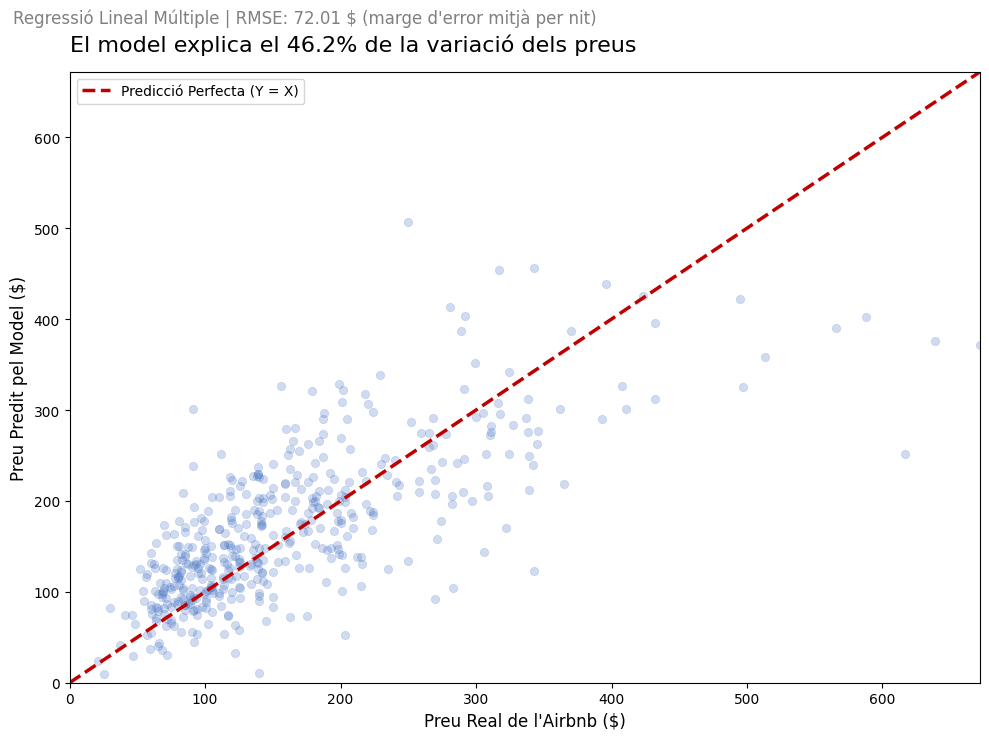


Les 4 variables més significatives segons el test F-regression són:
['num__bathrooms', 'num__accommodates', 'num__bedrooms', 'num__beds']


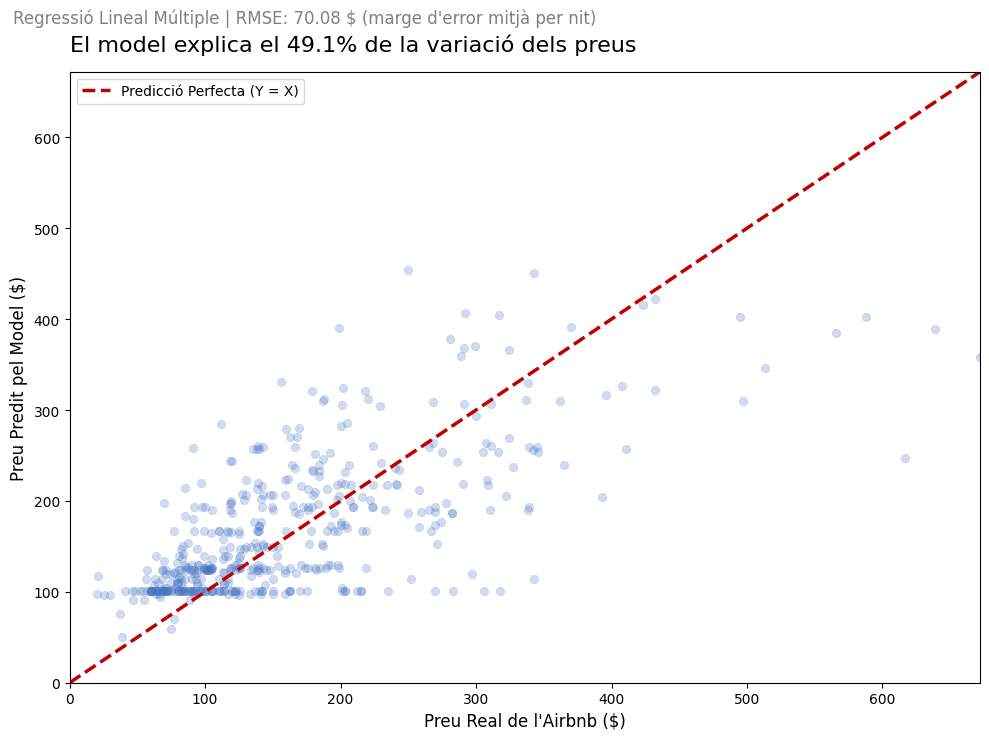

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm # Per a mapes de colors avançats

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

CARPETA_SORTIDA = "outputs/grafics"

df = pd.read_csv("dataset/listings.csv.gz", compression="gzip")

df["price_clean"] = (
    df["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

features = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes"
]

target = "price_clean"

df_model = df[features + [target]].copy()

# Eliminem files sense preu
df_model = df_model.dropna()

# Eliminem preus extrems per no distorsionar el model
limit_preu = df_model[target].quantile(0.99)
df_model = df_model[df_model[target] <= limit_preu]

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identifiquem les columnes categòriques i numèriques
categorical_cols = ["neighbourhood_cleansed", "room_type", "property_type"]
numerical_cols = [col for col in features if col not in categorical_cols]

# Preprocessing: One-Hot Encoding per a variables categòriques i mantenir les numèriques sense canvis
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

model = LinearRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(10, 8))

# Dibuixem el gràfic de dispersió (Observacions Reals vs Prediccions)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, color="#4472C4", edgecolor=None)

# Dibuixem la recta de predicció perfecta (on el valor real és igual al predit)
max_val = y_test.max()
lims = [0, max_val]
plt.plot(lims, lims, color="#C00000", linestyle="--", linewidth=2.5, label="Predicció Perfecta (Y = X)")

# Títols orientats a conclusions
plt.title(f"El model explica el {r2*100:.1f}% de la variació dels preus", fontsize=16, loc="left", pad=15)

# Títol secundari corregit: l'RMSE ja està en dòlars reals
plt.suptitle(f"Regressió Lineal Múltiple | RMSE: {rmse:.2f} $ (marge d'error mitjà per nit)", 
             fontsize=12, color="gray", x=0.31, y=0.92)

plt.xlabel("Preu Real de l'Airbnb ($)", fontsize=12)
plt.ylabel("Preu Predit pel Model ($)", fontsize=12)
plt.xlim(lims)
plt.ylim(lims)
plt.legend(loc="upper left")
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    f"{CARPETA_SORTIDA}/regressio_lineal_asheville.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Fem proves seleccionant les variables més significatives segons el test F-regression
f_values, p_values = f_regression(X_train_encoded, y_train)

features_netes = preprocessor.get_feature_names_out()

importancia_df = pd.DataFrame({
    "Feature": features_netes,
    "F_value": f_values,
    "p_value": p_values
}).sort_values(by="F_value", ascending=False)

N_FEATURES = 4
top_indices = importancia_df.head(N_FEATURES).index.tolist()
top_features_names = importancia_df.head(N_FEATURES)["Feature"].tolist()

print(f"\nLes {N_FEATURES} variables més significatives segons el test F-regression són:")
print(top_features_names)

X_train_top = X_train_encoded[:, top_indices]
X_test_top = X_test_encoded[:, top_indices]

model_top = LinearRegression()
model_top.fit(X_train_top, y_train)

y_pred_top = model_top.predict(X_test_top)

r2_top = r2_score(y_test, y_pred_top)
rmse_top = np.sqrt(mean_squared_error(y_test, y_pred_top))

plt.figure(figsize=(10, 8))

# Dibuixem el gràfic de dispersió (Observacions Reals vs Prediccions)
sns.scatterplot(x=y_test, y=y_pred_top, alpha=0.25, color="#4472C4", edgecolor=None)

# Dibuixem la recta de predicció perfecta (on el valor real és igual al predit)
max_val = y_test.max()
lims = [0, max_val]
plt.plot(lims, lims, color="#C00000", linestyle="--", linewidth=2.5, label="Predicció Perfecta (Y = X)")

# Títols orientats a conclusions
plt.title(f"El model explica el {r2_top*100:.1f}% de la variació dels preus", fontsize=16, loc="left", pad=15)

# Títol secundari corregit: l'RMSE ja està en dòlars reals
plt.suptitle(f"Regressió Lineal Múltiple | RMSE: {rmse_top:.2f} $ (marge d'error mitjà per nit)", 
             fontsize=12, color="gray", x=0.31, y=0.92)

plt.xlabel("Preu Real de l'Airbnb ($)", fontsize=12)
plt.ylabel("Preu Predit pel Model ($)", fontsize=12)
plt.xlim(lims)
plt.ylim(lims)
plt.legend(loc="upper left")
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    f"{CARPETA_SORTIDA}/regressio_lineal_top_features_asheville.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

APRENENTATGE SUPERVISAT CLASSIFICACIÓ

Distribució de les categories de preu:
price_category
50-150     1314
150-300     708
300+        249
0-50         73
Name: count, dtype: int64
Report de classificació:
              precision    recall  f1-score   support

        0-50       0.34      0.79      0.48        14
     150-300       0.52      0.48      0.50       142
        300+       0.42      0.58      0.49        50
      50-150       0.81      0.73      0.77       263

    accuracy                           0.64       469
   macro avg       0.52      0.64      0.56       469
weighted avg       0.67      0.64      0.65       469



c:\Users\alexb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


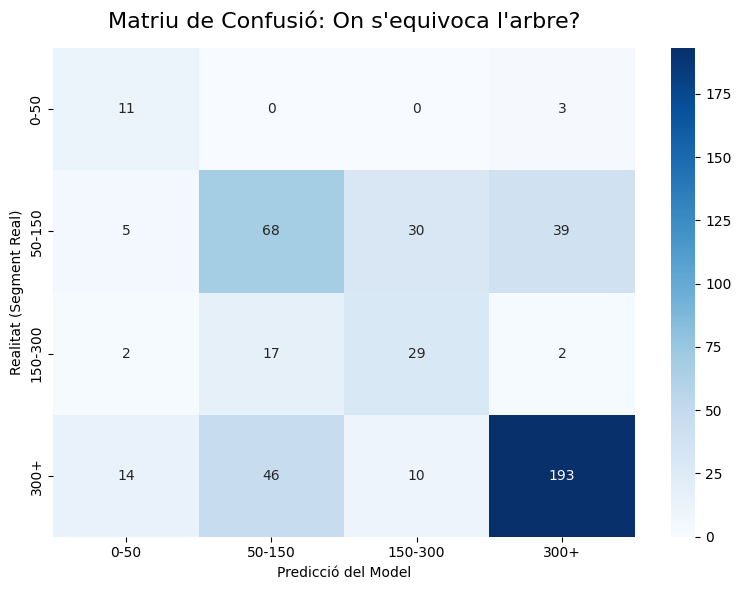

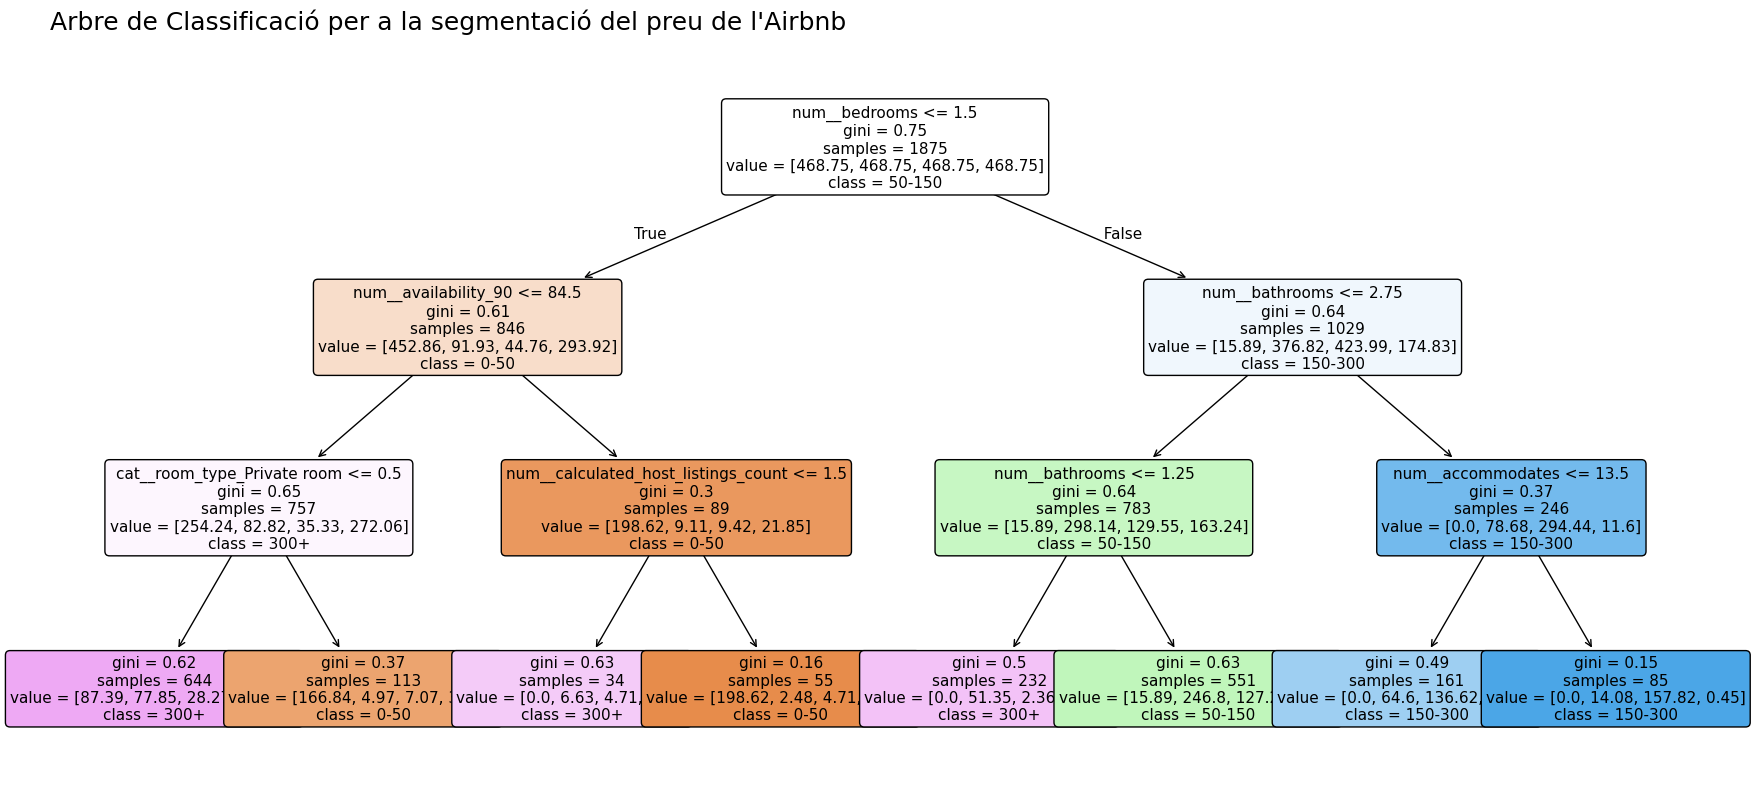

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm # Per a mapes de colors avançats

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

CARPETA_SORTIDA = "outputs/grafics"

df = pd.read_csv("dataset/listings.csv.gz", compression="gzip")



df["price_clean"] = (
    df["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

features = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes"
]

target = "price_clean"

df_model = df[features + [target]].copy()

df = df_model.dropna()

bins = [0, 50, 150, 300, np.inf]
labels = ['0-50', '50-150', '150-300', '300+']

df['price_category'] = pd.cut(df['price_clean'], bins=bins, labels=labels)

print("Distribució de les categories de preu:")
print(df['price_category'].value_counts())

X = df.drop(columns=['price_clean', 'price_category'])
y = df['price_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identifiquem les columnes categòriques i numèriques
categorical_cols = ["neighbourhood_cleansed", "room_type", "property_type"]
numerical_cols = [col for col in features if col not in categorical_cols]

# Preprocessing: One-Hot Encoding per a variables categòriques i mantenir les numèriques sense canvis
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

model_arbre_cat = DecisionTreeClassifier(random_state=42, max_depth=3, class_weight='balanced')
model_arbre_cat.fit(X_train_encoded, y_train)

y_pred_cat = model_arbre_cat.predict(X_test_encoded)

print("Report de classificació:")
print(classification_report(y_test, y_pred_cat))

cm = confusion_matrix(y_test, y_pred_cat)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Matriu de Confusió: On s'equivoca l'arbre?", fontsize=16, pad=15)
plt.xlabel("Predicció del Model")
plt.ylabel("Realitat (Segment Real)")
plt.tight_layout()

plt.savefig(f"{CARPETA_SORTIDA}/matriu_confusio.png", dpi=300, bbox_inches="tight")

plt.show()

# DIBUIX DE L'ARBRE DE CLASSIFICACIÓ
plt.figure(figsize=(18, 8))
plot_tree(
    model_arbre_cat,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=labels,
    filled=True,
    rounded=True,
    fontsize=11,
    precision=2
)

plt.title("Arbre de Classificació per a la segmentació del preu de l'Airbnb", fontsize=18, loc="left", pad=20)
plt.tight_layout()

plt.savefig(f"{CARPETA_SORTIDA}/arbre_classificacio.png", dpi=300, bbox_inches="tight")

plt.show()

APRENENTATGE NO SUPERVISAT

Files inicials: 2852
Columnes inicials: 79

Files utilitzades pel model no supervisat: 2511
Dimensions despres del preprocessament: (2511, 78)

RESULTATS KMEANS
 k   inertia  silhouette
 2 52753.698       0.131
 3 46846.090       0.144
 4 42272.324       0.160
 5 38333.129       0.183
 6 36061.116       0.190
 7 34113.408       0.141
 8 32429.686       0.149

Millor k segons silhouette: 6


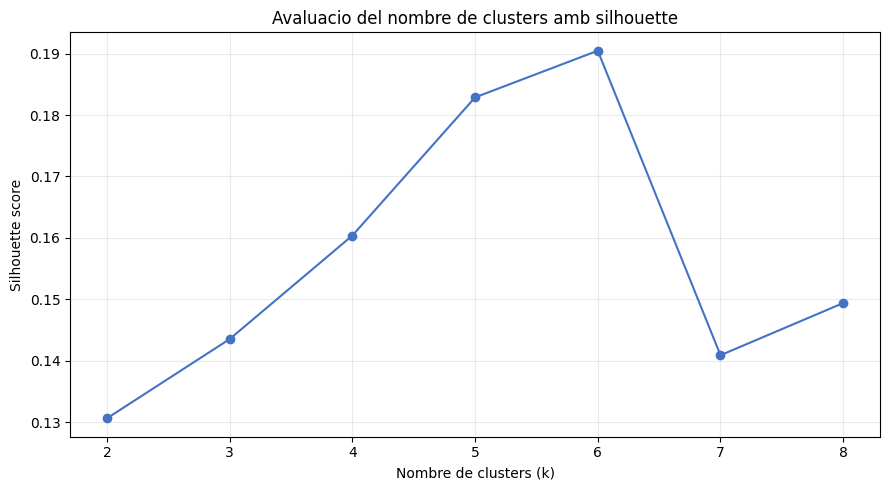

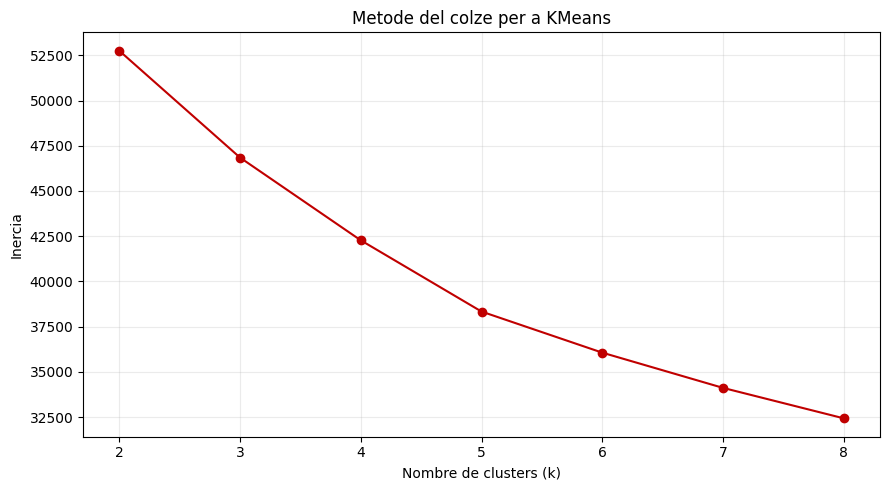


Silhouette final KMeans: 0.19

Distribucio de clusters:
cluster_kmeans
0     470
1     580
2     110
3      78
4      35
5    1238
Name: count, dtype: int64


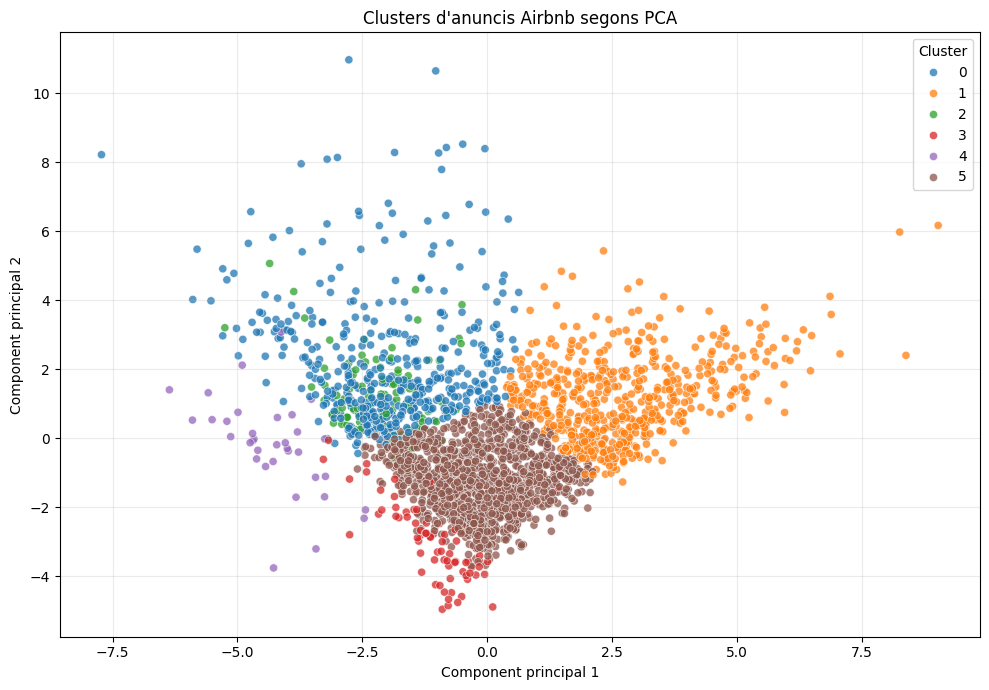


PERFIL DELS CLUSTERS
                anuncis  barri_mes_frequent tipus_habitacio_mes_frequent tipus_propietat_mes_frequent  price_clean  accommodates  bedrooms  beds  minimum_nights  availability_90  availability_365  number_of_reviews  number_of_reviews_ltm  reviews_per_month  review_scores_rating  estimated_occupancy_l365d  estimated_revenue_l365d  host_response_rate_clean  host_acceptance_rate_clean  host_listings_count  host_total_listings_count  calculated_host_listings_count  calculated_host_listings_count_entire_homes  calculated_host_listings_count_private_rooms  host_is_superhost_num  instant_bookable_num
cluster_kmeans                                                                                                                                                                                                                                                                                                                                                                           

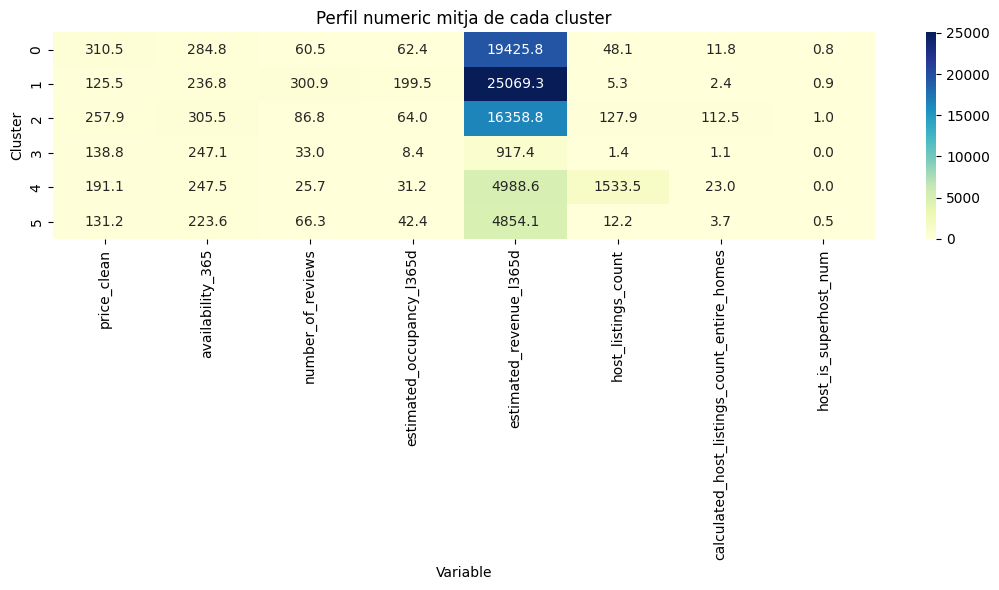


RESULTATS DBSCAN
 eps  clusters  soroll  silhouette_sense_soroll
 1.5         5    2398                    0.651
 2.0         9    1717                    0.140
 2.5         5     728                    0.115
 3.0         6     303                    0.297
 3.5         5     127                    0.216

FITXERS GENERATS
- outputs/grafics/nosupervisat_silhouette_kmeans.png
- outputs/grafics/nosupervisat_colze_kmeans.png
- outputs/grafics/nosupervisat_clusters_pca.png
- outputs/grafics/nosupervisat_perfil_clusters_heatmap.png
- outputs/nosupervisat_perfil_clusters.csv
- outputs/nosupervisat_resultats_kmeans.csv
- outputs/nosupervisat_resultats_dbscan.csv
- outputs/nosupervisat_anuncis_clusteritzats.csv


In [3]:
# ============================================================
# APRENENTATGE NO SUPERVISAT - AGRUPACIO D'ANUNCIS AIRBNB
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ============================================================
# 1. CONFIGURACIO GENERAL
# ============================================================

RUTA_DATASET_GZ = "dataset/listings.csv.gz"
RUTA_DATASET_CSV = "dataset/listings.csv"
CARPETA_SORTIDA = "outputs/grafics"
CARPETA_DADES = "outputs"

os.makedirs(CARPETA_SORTIDA, exist_ok=True)
os.makedirs(CARPETA_DADES, exist_ok=True)

MAIN_BLUE = "#4472C4"
ALERT_RED = "#C00000"
CLEAN_GREEN = "#70AD47"


def crear_one_hot_encoder():
    """Compatibilitat amb versions noves i antigues de scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def convertir_percentatge(serie):
    return (
        serie.astype(str)
        .str.replace("%", "", regex=False)
        .replace("nan", np.nan)
        .astype(float)
    )


# ============================================================
# 2. CARREGAR DATASET
# ============================================================

if os.path.exists(RUTA_DATASET_GZ):
    df = pd.read_csv(RUTA_DATASET_GZ, compression="gzip")
elif os.path.exists(RUTA_DATASET_CSV):
    df = pd.read_csv(RUTA_DATASET_CSV)
else:
    raise FileNotFoundError("No s'ha trobat dataset/listings.csv.gz ni dataset/listings.csv")

print("Files inicials:", len(df))
print("Columnes inicials:", len(df.columns))

# ============================================================
# 3. NETEJA DE VARIABLES
# ============================================================

df["price_clean"] = (
    df["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

df["host_response_rate_clean"] = convertir_percentatge(df["host_response_rate"])
df["host_acceptance_rate_clean"] = convertir_percentatge(df["host_acceptance_rate"])
df["host_is_superhost_num"] = df["host_is_superhost"].map({"t": 1, "f": 0})
df["instant_bookable_num"] = df["instant_bookable"].map({"t": 1, "f": 0})

# Eliminem preus extrems perque no dominin la distancia dels clusters.
limit_preu_99 = df["price_clean"].quantile(0.99)
df = df[df["price_clean"] <= limit_preu_99].copy()

# ============================================================
# 4. VARIABLES PER A L'ANALISI NO SUPERVISADA
# ============================================================

# Objectiu: agrupar anuncis segons el perfil d'explotacio turistica i d'amfitrio.
num_features = [
    "price_clean",
    "accommodates",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month",
    "review_scores_rating",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "host_response_rate_clean",
    "host_acceptance_rate_clean",
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "host_is_superhost_num",
    "instant_bookable_num",
]

cat_features = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
]

features = num_features + cat_features
df_model = df[features].copy()

print("\nFiles utilitzades pel model no supervisat:", len(df_model))

# ============================================================
# 5. PREPROCESSAMENT
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", crear_one_hot_encoder())
            ]),
            cat_features
        )
    ]
)

X_prepared = preprocessor.fit_transform(df_model)

print("Dimensions despres del preprocessament:", X_prepared.shape)

# ============================================================
# 6. SELECCIO DEL NOMBRE DE CLUSTERS AMB KMEANS
# ============================================================

resultats_k = []

for k in range(2, 9):
    model_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    etiquetes = model_kmeans.fit_predict(X_prepared)
    sil = silhouette_score(X_prepared, etiquetes)
    resultats_k.append({
        "k": k,
        "inertia": model_kmeans.inertia_,
        "silhouette": sil
    })

resultats_k_df = pd.DataFrame(resultats_k)
millor_k = int(resultats_k_df.sort_values("silhouette", ascending=False).iloc[0]["k"])

print("\nRESULTATS KMEANS")
print(resultats_k_df.round(3).to_string(index=False))
print("\nMillor k segons silhouette:", millor_k)

plt.figure(figsize=(9, 5))
plt.plot(resultats_k_df["k"], resultats_k_df["silhouette"], marker="o", color=MAIN_BLUE)
plt.title("Avaluacio del nombre de clusters amb silhouette")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(f"{CARPETA_SORTIDA}/nosupervisat_silhouette_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(resultats_k_df["k"], resultats_k_df["inertia"], marker="o", color=ALERT_RED)
plt.title("Metode del colze per a KMeans")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(f"{CARPETA_SORTIDA}/nosupervisat_colze_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 7. MODEL FINAL KMEANS
# ============================================================

kmeans_final = KMeans(
    n_clusters=millor_k,
    random_state=42,
    n_init=20
)

df_resultat = df.copy()
df_resultat["cluster_kmeans"] = kmeans_final.fit_predict(X_prepared)

silhouette_final = silhouette_score(X_prepared, df_resultat["cluster_kmeans"])

print("\nSilhouette final KMeans:", round(silhouette_final, 3))
print("\nDistribucio de clusters:")
print(df_resultat["cluster_kmeans"].value_counts().sort_index())

# ============================================================
# 8. VISUALITZACIO DELS CLUSTERS AMB PCA
# ============================================================

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared)

df_resultat["pca_1"] = X_pca[:, 0]
df_resultat["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_resultat,
    x="pca_1",
    y="pca_2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.75,
    s=35
)
plt.title("Clusters d'anuncis Airbnb segons PCA")
plt.xlabel("Component principal 1")
plt.ylabel("Component principal 2")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(f"{CARPETA_SORTIDA}/nosupervisat_clusters_pca.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 9. PERFIL I INTERPRETACIO DELS CLUSTERS
# ============================================================

perfil_numeric = (
    df_resultat
    .groupby("cluster_kmeans")[num_features]
    .mean()
    .round(2)
)

perfil_extra = (
    df_resultat
    .groupby("cluster_kmeans")
    .agg(
        anuncis=("id", "count"),
        barri_mes_frequent=("neighbourhood_cleansed", lambda x: x.mode().iloc[0]),
        tipus_habitacio_mes_frequent=("room_type", lambda x: x.mode().iloc[0]),
        tipus_propietat_mes_frequent=("property_type", lambda x: x.mode().iloc[0])
    )
)

perfil_clusters = perfil_extra.join(perfil_numeric)

print("\nPERFIL DELS CLUSTERS")
print(perfil_clusters.to_string())

perfil_clusters.to_csv(f"{CARPETA_DADES}/nosupervisat_perfil_clusters.csv")
resultats_k_df.to_csv(f"{CARPETA_DADES}/nosupervisat_resultats_kmeans.csv", index=False)
df_resultat[[
    "id",
    "name",
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "price_clean",
    "cluster_kmeans",
    "pca_1",
    "pca_2"
]].to_csv(f"{CARPETA_DADES}/nosupervisat_anuncis_clusteritzats.csv", index=False)

plt.figure(figsize=(11, 6))
sns.heatmap(
    perfil_numeric[[
        "price_clean",
        "availability_365",
        "number_of_reviews",
        "estimated_occupancy_l365d",
        "estimated_revenue_l365d",
        "host_listings_count",
        "calculated_host_listings_count_entire_homes",
        "host_is_superhost_num"
    ]],
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Perfil numeric mitja de cada cluster")
plt.xlabel("Variable")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig(f"{CARPETA_SORTIDA}/nosupervisat_perfil_clusters_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 10. COMPARACIO AMB DBSCAN
# ============================================================

resultats_dbscan = []

for eps in [1.5, 2.0, 2.5, 3.0, 3.5]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    etiquetes_db = dbscan.fit_predict(X_prepared)

    n_clusters = len(set(etiquetes_db)) - (1 if -1 in etiquetes_db else 0)
    soroll = int(np.sum(etiquetes_db == -1))

    if n_clusters >= 2:
        mascara_valids = etiquetes_db != -1
        sil_db = silhouette_score(X_prepared[mascara_valids], etiquetes_db[mascara_valids])
    else:
        sil_db = np.nan

    resultats_dbscan.append({
        "eps": eps,
        "clusters": n_clusters,
        "soroll": soroll,
        "silhouette_sense_soroll": sil_db
    })

resultats_dbscan_df = pd.DataFrame(resultats_dbscan)

print("\nRESULTATS DBSCAN")
print(resultats_dbscan_df.round(3).to_string(index=False))

resultats_dbscan_df.to_csv(f"{CARPETA_DADES}/nosupervisat_resultats_dbscan.csv", index=False)

print("\nFITXERS GENERATS")
print(f"- {CARPETA_SORTIDA}/nosupervisat_silhouette_kmeans.png")
print(f"- {CARPETA_SORTIDA}/nosupervisat_colze_kmeans.png")
print(f"- {CARPETA_SORTIDA}/nosupervisat_clusters_pca.png")
print(f"- {CARPETA_SORTIDA}/nosupervisat_perfil_clusters_heatmap.png")
print(f"- {CARPETA_DADES}/nosupervisat_perfil_clusters.csv")
print(f"- {CARPETA_DADES}/nosupervisat_resultats_kmeans.csv")
print(f"- {CARPETA_DADES}/nosupervisat_resultats_dbscan.csv")
print(f"- {CARPETA_DADES}/nosupervisat_anuncis_clusteritzats.csv")
